# Gait curve comparision

I have foudn a paper that brings insights into how to work and compare gait curves.
Paper: https://pmc.ncbi.nlm.nih.gov/articles/PMC1208939/#sec14

### Compare visualizations of two samples:

In [3]:
from core.matlab_data_loader import MatlabDataLoader, segment_ts_by_stance_phase
from core.timeseries import get_group_curves, plot_group_curves
import kineticstoolkit as ktk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, envelope, hilbert
from scipy.interpolate import interp1d

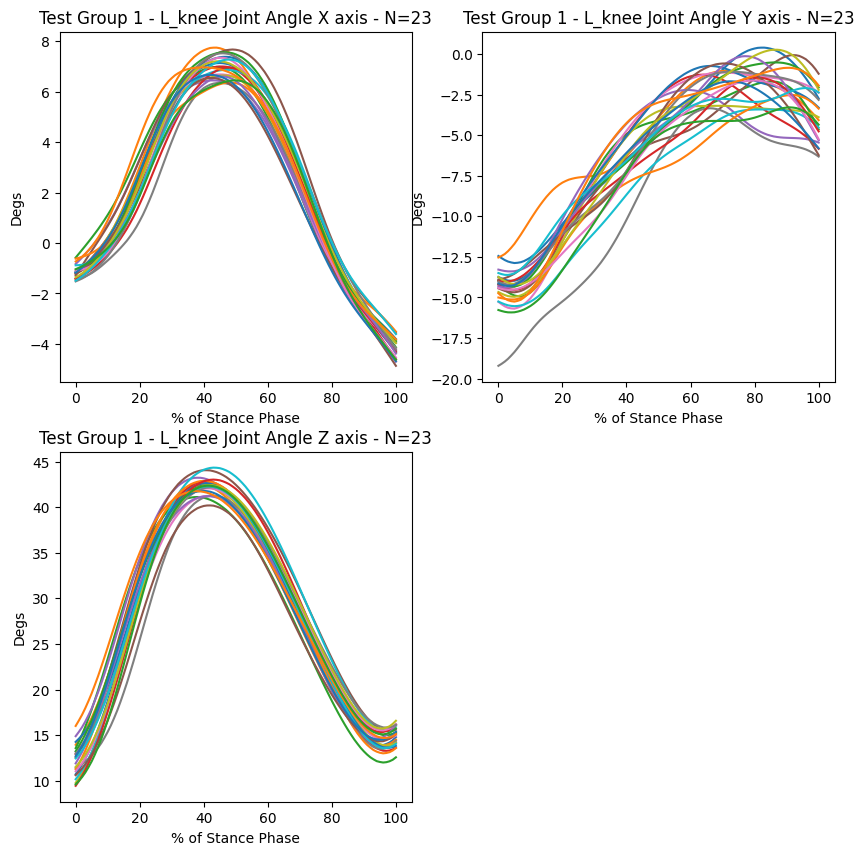

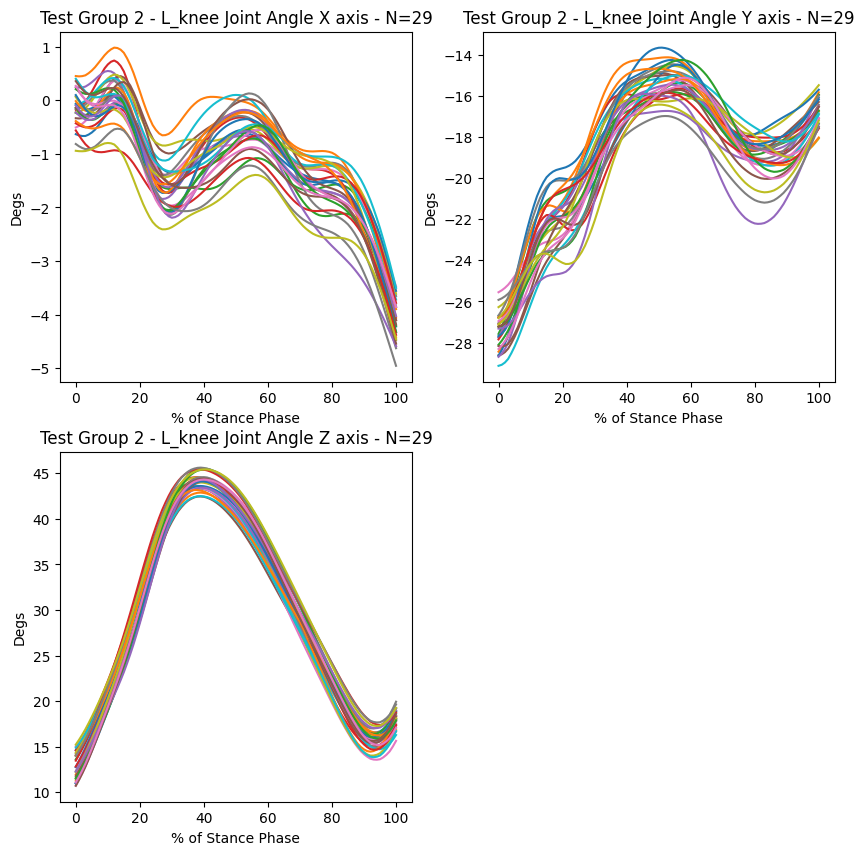

In [4]:
L_KNEE_JOINT_NAME = "L_knee"

loader = MatlabDataLoader()

one_session = loader.get_successful_sessions()[16]
one_session_ts = loader.get_joint_angles_timeseries(one_session, L_KNEE_JOINT_NAME, normalized=False, include_events=True)
test1_group = get_group_curves(one_session_ts)
plot_group_curves(test1_group, "Test Group 1", f"{L_KNEE_JOINT_NAME} Joint Angle", "Degs", "% of Stance Phase")

other_session = loader.get_successful_sessions()[1200]
other_session_ts = loader.get_joint_angles_timeseries(other_session, L_KNEE_JOINT_NAME, normalized=False, include_events=True)
test2_group = get_group_curves(other_session_ts)
plot_group_curves(test2_group, "Test Group 2", f"{L_KNEE_JOINT_NAME} Joint Angle", "Degs", "% of Stance Phase")

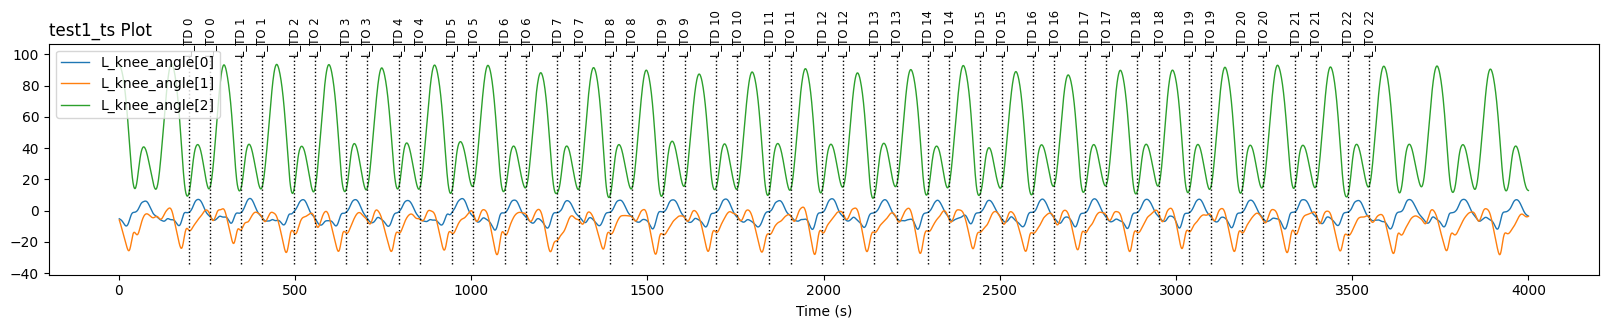

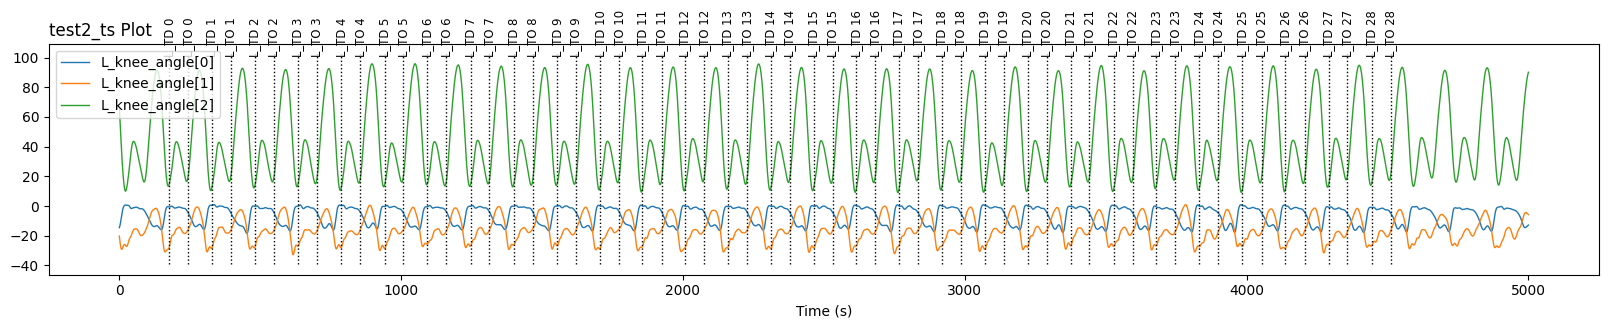

In [5]:
plt.figure(figsize=(20, 3))
one_session_ts.plot()
plt.title("test1_ts Plot", loc="left")
plt.figure(figsize=(20, 3))
other_session_ts.plot()
plt.title("test2_ts Plot", loc="left")
plt.show()

In [6]:
# GRoups for Similarity Test:
group_1 = get_group_curves(one_session_ts)
print("Group 1 shape: ", group_1.shape)
print("Group 1: Session ID: ", one_session)

group_2 = get_group_curves(other_session_ts)
print("Group 2 shape: ", group_2.shape)
print("Group 2: Session ID: ", other_session)

group_3 = get_group_curves(other_session_ts)
print("Group 3 shape: ", group_3.shape)
print("Group 3: Session ID: ", other_session)


Group 1 shape:  (23, 101, 3)
Group 1: Session ID:  100016_20110329T161600
Group 2 shape:  (29, 101, 3)
Group 2: Session ID:  101139_20140711T132738
Group 3 shape:  (29, 101, 3)
Group 3: Session ID:  101139_20140711T132738


# Approach 1:

X_list shape:  (23, 101)
Y_list shape:  (29, 101)


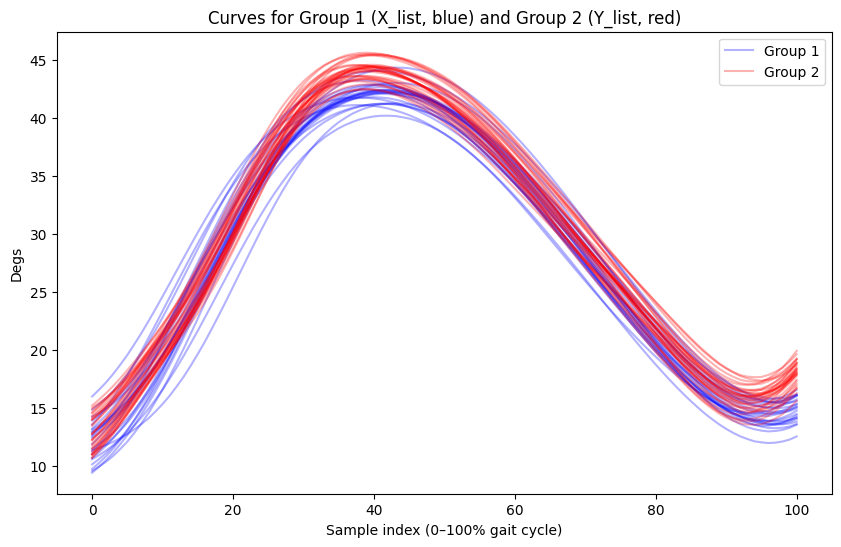


Results:
--------------------------------------------------
p-value = 5.00e-05 (0.000050)
TAN = 8.303  m* = 1


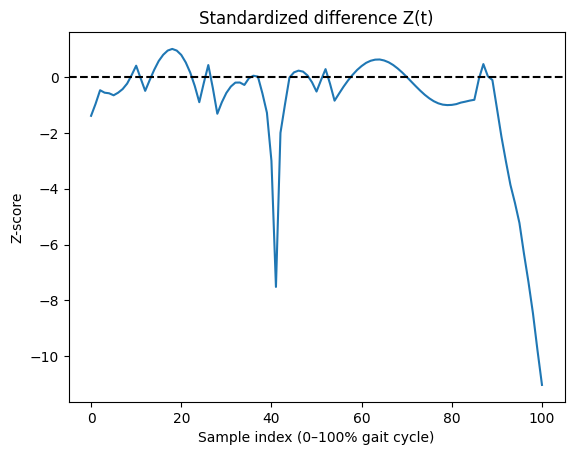

In [12]:
# C:
import numpy as np
from scipy.interpolate import interp1d

# -------------------------
# Utilities
# -------------------------
def resample_curves(curves, T=100, kind='cubic'):
    """
    curves : array-like (n_curves, orig_len) or list of 1D arrays
    returns: np.ndarray shape (n_curves, T)
    """
    curves = np.asarray([np.asarray(c) for c in curves])
    n, orig = curves.shape
    if orig == T:
        return curves.astype(float)
    old_t = np.linspace(0, 1, orig)
    new_t = np.linspace(0, 1, T)
    out = np.zeros((n, T), dtype=float)
    for i in range(n):
        f = interp1d(old_t, curves[i], kind=kind, fill_value='extrapolate')
        out[i] = f(new_t)
    return out

def dtw_path(a, b):
    """
    Simple DTW to get warping path between two 1D arrays a (reference) and b (to-warp).
    Returns list of (i,j) index pairs (i index into a, j index into b).
    (Quadratic complexity; OK for typical T~100-500.)
    """
    a = np.asarray(a)
    b = np.asarray(b)
    n, m = len(a), len(b)
    D = np.full((n, m), np.inf)
    D[0, 0] = abs(a[0] - b[0])
    for i in range(1, n):
        D[i, 0] = D[i-1, 0] + abs(a[i] - b[0])
    for j in range(1, m):
        D[0, j] = D[0, j-1] + abs(a[0] - b[j])
    for i in range(1, n):
        for j in range(1, m):
            D[i, j] = min(D[i-1, j], D[i, j-1], D[i-1, j-1]) + abs(a[i] - b[j])
    # backtrace
    i, j = n-1, m-1
    path = []
    while (i > 0) or (j > 0):
        path.append((i, j))
        if i == 0:
            j -= 1
        elif j == 0:
            i -= 1
        else:
            choices = [D[i-1, j], D[i, j-1], D[i-1, j-1]]
            arg = int(np.argmin(choices))
            if arg == 0:
                i -= 1
            elif arg == 1:
                j -= 1
            else:
                i -= 1
                j -= 1
    path.append((0, 0))
    path.reverse()
    return path

def warp_curves_by_dtw(mu_ref, mu_mov, curves_mov):
    """
    Warp the group curves_mov so their mean (mu_mov) aligns to mu_ref using DTW path.
    Returns warped curves with same length as mu_ref.
    """
    mu_ref = np.asarray(mu_ref)
    mu_mov = np.asarray(mu_mov)
    curves_mov = np.asarray(curves_mov)
    n_ref = len(mu_ref)
    n_mov = len(mu_mov)
    path = dtw_path(mu_ref, mu_mov)  # pairs (i_ref, j_mov)

    # For each j (index in moving mean), compute the average i's that map to it
    from collections import defaultdict
    map_j_to_is = defaultdict(list)
    for i, j in path:
        map_j_to_is[j].append(i)
    # Build arrays of points (tX_mapped_j, tY_j)
    tY = np.linspace(0, 1, n_mov)
    tX = np.linspace(0, 1, n_ref)
    tX_mapped = []
    tY_list = []
    for j in range(n_mov):
        is_for_j = map_j_to_is.get(j, [0])
        mean_i = np.mean(is_for_j)
        tX_mapped.append(tX[int(round(mean_i))])
        tY_list.append(tY[j])
    tX_mapped = np.asarray(tX_mapped)
    tY_list = np.asarray(tY_list)

    # Sort by tX_mapped (should be monotonic-ish)
    order = np.argsort(tX_mapped)
    tX_mapped_s = tX_mapped[order]
    tY_s = tY_list[order]

    # Remove duplicates in tX_mapped by averaging corresponding tY
    uniq_x, inv_idx = np.unique(np.round(tX_mapped_s, 8), return_inverse=True)
    uniq_y = np.zeros_like(uniq_x)
    for k in range(len(uniq_x)):
        uniq_y[k] = tY_s[inv_idx == k].mean()

    # Interpolate the inverse mapping: for each tX_grid -> tY_sample
    f_inv = interp1d(uniq_x, uniq_y, bounds_error=False,
                     fill_value=(uniq_y[0], uniq_y[-1]))
    tX_grid = np.linspace(0, 1, n_ref)
    tY_samples = f_inv(tX_grid)      # values in [0,1] (positions on original moving curve)

    # Sample each moving curve at tY_samples
    out = np.zeros((curves_mov.shape[0], n_ref))
    for idx in range(curves_mov.shape[0]):
        f = interp1d(np.linspace(0, 1, n_mov), curves_mov[idx], kind='cubic',
                     fill_value='extrapolate')
        out[idx] = f(tY_samples)
    return out

# -------------------------
# Main function: adaptive Neyman test for two groups of curves
# -------------------------
def compare_curve_groups_adaptive_neyman(X_curves, Y_curves, register=True, nsim=10000, random_state=None):
    """
    Compare two groups of curves (lists or arrays of 1D arrays) using the paper's approach:
    - optional registration (DTW aligning means),
    - standardized difference Z(t),
    - Fourier pairing -> E vector,
    - adaptive Neyman statistic (choose best m),
    - Monte Carlo p-value (simulate normal vectors).
    Returns a dict with p-value, test statistic, m_star and diagnostic arrays.
    (Implementation adapted from Chau et al., JNER 2005). :contentReference[oaicite:3]{index=3}
    """
    rng = np.random.default_rng(random_state)
    # X = resample_curves(X_curves, 101)
    # Y = resample_curves(Y_curves, 101)
    X = X_curves
    Y = Y_curves
    nX = X.shape[0]; nY = Y.shape[0]

    # Optional registration: align group means (paper step 3 recommends aligning means).
    if register:
        muX = X.mean(axis=0)
        muY = Y.mean(axis=0)
        Y = warp_curves_by_dtw(muX, muY, Y)

    # Recompute means / variances after warping
    muX = X.mean(axis=0)
    muY = Y.mean(axis=0)
    varX = X.var(axis=0, ddof=0)
    varY = Y.var(axis=0, ddof=0)

    # Standardized difference Z(t) = (muX - muY) / sqrt( varX/nX + varY/nY )
    denom = np.sqrt(varX / float(nX) + varY / float(nY))
    denom[denom == 0] = 1e-12
    Z = (muX - muY) / denom    # length T

    # Discrete Fourier transform of Z(t)
    coeffs = np.fft.rfft(Z)    # complex coefficients for k=0..T/2

    # Build real-vector E by pairing real and imag parts as in the paper: [Re(k=0), Re(1), Im(1), Re(2), Im(2), ..., Re(T/2)]
    E_list = []
    E_list.append(coeffs[0].real)           # k=0
    for k in range(1, len(coeffs)-1):
        E_list.append(coeffs[k].real)
        E_list.append(coeffs[k].imag)
    if len(coeffs) > 1:
        E_list.append(coeffs[-1].real)     # Nyquist (real)
    E = np.array(E_list, dtype=float)
    L = len(E)

    # Adaptive Neyman style statistic:
    E2 = E**2
    varE2 = np.var(E2, ddof=0)
    if varE2 <= 0:
        varE2 = 1e-12

    # For m = 1..L compute S_m = (sum_{i=1}^m (E_i^2 - 1)) / sqrt(m * Var(E^2))
    cum = np.cumsum(E2 - 1.0)
    m_idx = np.arange(1, L+1)
    S = cum / np.sqrt(m_idx * varE2)
    TAN_obs = np.max(S)
    m_star = np.argmax(S) + 1

    # Monte Carlo: simulate nsim standard normal vectors of length L and compute TAN for each
    # (paper suggests simulating many standard normals to approximate null). :contentReference[oaicite:5]{index=5}
    sim = rng.normal(size=(nsim, L))
    sim_E2 = sim**2
    sim_cum = np.cumsum(sim_E2 - 1.0, axis=1)
    denom_sim = np.sqrt(m_idx * varE2)   # shape (L,)
    Ssim = sim_cum / denom_sim  # shape (nsim, L)
    TAN_sim = Ssim.max(axis=1)
    pval = (np.sum(TAN_sim >= TAN_obs) + 1) / (nsim + 1)  # add-1 smoothing

    return dict(
        p_value = pval,
        TAN = float(TAN_obs),
        m_star = int(m_star),
        E = E,
        S = S,
        Z = Z,
        muX = muX,
        muY = muY,
        varX = varX,
        varY = varY,
        nsim = nsim
    )



# Suppose you have two groups (lists) of 1D numpy arrays, Xlist and Ylist:
RANDOM_SEED = 42

X_list =  group_1[:, :, 2]  # Only Z axis -> shape → (22, 101)
Y_list = group_2[:, :, 2]  # Only Z axis -> shape → (22, 101)
# Y_list = X_list[5:10]

print("X_list shape: ", X_list.shape)
print("Y_list shape: ", Y_list.shape)

plt.figure(figsize=(10, 6))
for i in range(X_list.shape[0]):
    plt.plot(X_list[i], color='blue', alpha=0.3, label='Group 1' if i == 0 else "")
for i in range(Y_list.shape[0]):
    plt.plot(Y_list[i], color='red', alpha=0.3, label='Group 2' if i == 0 else "")
plt.title("Curves for Group 1 (X_list, blue) and Group 2 (Y_list, red)")
plt.xlabel("Sample index (0–100% gait cycle)")
plt.ylabel("Degs")
plt.legend()
plt.show()


result = compare_curve_groups_adaptive_neyman(
    X_list, Y_list,
    register=True,       # Align curves to remove phase variation
    nsim=20000,          # Monte Carlo iterations for p-value
    random_state=RANDOM_SEED
)

print("\nResults:")
print("-"*50)
print(f"p-value = {result['p_value']:.2e} ({result['p_value']:.6f})")
print(f"TAN = {result['TAN']:.3f}  m* = {result['m_star']}")

plt.plot(result['Z'])
plt.axhline(0, color='black', linestyle='--')
plt.title("Standardized difference Z(t)")
plt.xlabel("Sample index (0–100% gait cycle)")
plt.ylabel("Z-score")
plt.show()

In [13]:
result_same = compare_curve_groups_adaptive_neyman(
    X_list, X_list[5:10],
    register=False,   # Turn off registration to see baseline behavior
    nsim=20000,
    random_state=42
)
print(result_same['p_value'])

4.999750012499375e-05


X_list shape:  (23, 101)
Y_list shape:  (29, 101)


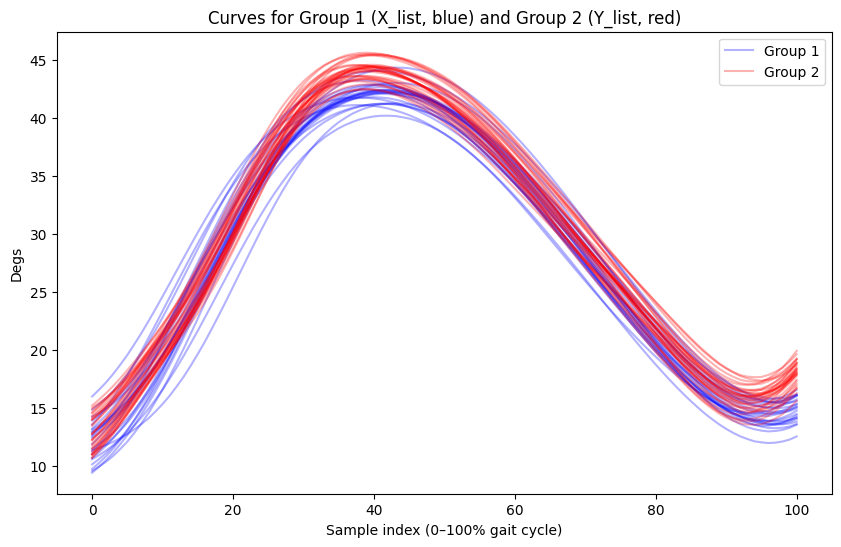


Results:
--------------------------------------------------
p-value = 2.00e-04 (0.000200)
TAN = 9.887  m* = 1


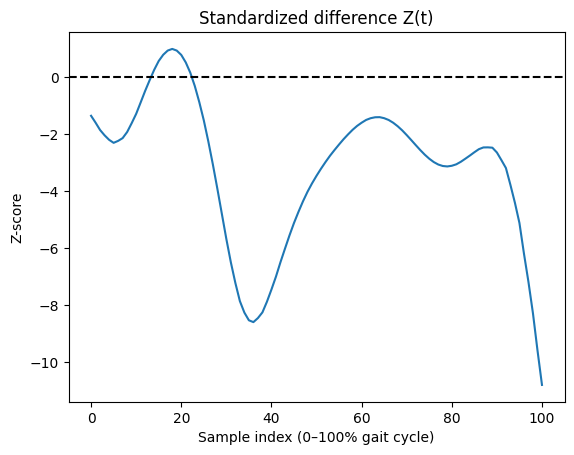

In [14]:
## Attempt 2:
import numpy as np
from scipy.interpolate import interp1d

# --- Optional DTW alignment helper ---
def dtw_path(a, b):
    a = np.asarray(a)
    b = np.asarray(b)
    n, m = len(a), len(b)
    D = np.full((n, m), np.inf)
    D[0, 0] = abs(a[0] - b[0])
    for i in range(1, n):
        D[i, 0] = D[i-1, 0] + abs(a[i] - b[0])
    for j in range(1, m):
        D[0, j] = D[0, j-1] + abs(a[0] - b[j])
    for i in range(1, n):
        for j in range(1, m):
            D[i, j] = min(D[i-1, j], D[i, j-1], D[i-1, j-1]) + abs(a[i] - b[j])
    # backtrace
    i, j = n-1, m-1
    path = []
    while (i > 0) or (j > 0):
        path.append((i, j))
        if i == 0:
            j -= 1
        elif j == 0:
            i -= 1
        else:
            choices = [D[i-1, j], D[i, j-1], D[i-1, j-1]]
            arg = int(np.argmin(choices))
            if arg == 0:
                i -= 1
            elif arg == 1:
                j -= 1
            else:
                i -= 1
                j -= 1
    path.append((0, 0))
    path.reverse()
    return path

def warp_curves_by_dtw(mu_ref, mu_mov, curves_mov):
    mu_ref = np.asarray(mu_ref)
    mu_mov = np.asarray(mu_mov)
    curves_mov = np.asarray(curves_mov)
    n_ref = len(mu_ref)
    n_mov = len(mu_mov)
    path = dtw_path(mu_ref, mu_mov)
    from collections import defaultdict
    map_j_to_is = defaultdict(list)
    for i, j in path:
        map_j_to_is[j].append(i)
    tY = np.linspace(0, 1, n_mov)
    tX = np.linspace(0, 1, n_ref)
    tX_mapped, tY_list = [], []
    for j in range(n_mov):
        is_for_j = map_j_to_is.get(j, [0])
        mean_i = np.mean(is_for_j)
        tX_mapped.append(tX[int(round(mean_i))])
        tY_list.append(tY[j])
    tX_mapped = np.asarray(tX_mapped)
    tY_list = np.asarray(tY_list)
    order = np.argsort(tX_mapped)
    tX_mapped_s = tX_mapped[order]
    tY_s = tY_list[order]
    uniq_x, inv_idx = np.unique(np.round(tX_mapped_s, 8), return_inverse=True)
    uniq_y = np.zeros_like(uniq_x)
    for k in range(len(uniq_x)):
        uniq_y[k] = tY_s[inv_idx == k].mean()
    f_inv = interp1d(uniq_x, uniq_y, bounds_error=False,
                     fill_value=(uniq_y[0], uniq_y[-1]))
    tX_grid = np.linspace(0, 1, n_ref)
    tY_samples = f_inv(tX_grid)
    out = np.zeros((curves_mov.shape[0], n_ref))
    for idx in range(curves_mov.shape[0]):
        f = interp1d(np.linspace(0, 1, n_mov), curves_mov[idx], kind='cubic',
                     fill_value='extrapolate')
        out[idx] = f(tY_samples)
    return out

# --- Main comparison function with permutation test ---
def compare_curve_groups_permutation(X_curves, Y_curves, register=False, n_perm=10000, random_state=None):
    """
    Compare two groups of pre-resampled curves using the Adaptive Neyman test + permutation p-value.
    
    X_curves: array (n1, n_samples)
    Y_curves: array (n2, n_samples)
    register: bool, whether to DTW-align means before comparison
    n_perm:   number of permutations
    """
    rng = np.random.default_rng(random_state)
    X = np.asarray(X_curves, dtype=float)
    Y = np.asarray(Y_curves, dtype=float)
    nX, T = X.shape
    nY, _ = Y.shape

    if register:
        muX = X.mean(axis=0)
        muY = Y.mean(axis=0)
        Y = warp_curves_by_dtw(muX, muY, Y)

    # --- Standardized difference Z(t) ---
    muX = X.mean(axis=0)
    muY = Y.mean(axis=0)
    varX = X.var(axis=0, ddof=1)
    varY = Y.var(axis=0, ddof=1)
    denom = np.sqrt(varX / nX + varY / nY)
    denom[denom == 0] = 1e-12
    Z = (muX - muY) / denom

    # --- Fourier coefficients -> real vector E ---
    coeffs = np.fft.rfft(Z)
    E_list = [coeffs[0].real]
    for k in range(1, len(coeffs)-1):
        E_list.append(coeffs[k].real)
        E_list.append(coeffs[k].imag)
    if len(coeffs) > 1:
        E_list.append(coeffs[-1].real)
    E = np.array(E_list, dtype=float)
    L = len(E)

    # --- Adaptive Neyman statistic ---
    E2 = E**2
    varE2 = np.var(E2, ddof=1)
    if varE2 <= 0:
        varE2 = 1e-12
    cum = np.cumsum(E2 - 1.0)
    m_idx = np.arange(1, L+1)
    S = cum / np.sqrt(m_idx * varE2)
    TAN_obs = np.max(S)
    m_star = np.argmax(S) + 1

    # --- Permutation null distribution ---
    pooled = np.vstack([X, Y])
    labels = np.array([0]*nX + [1]*nY)
    TAN_perm = np.zeros(n_perm)
    for b in range(n_perm):
        rng.shuffle(labels)
        Xb = pooled[labels == 0]
        Yb = pooled[labels == 1]
        muXb = Xb.mean(axis=0)
        muYb = Yb.mean(axis=0)
        varXb = Xb.var(axis=0, ddof=1)
        varYb = Yb.var(axis=0, ddof=1)
        denom_b = np.sqrt(varXb / Xb.shape[0] + varYb / Yb.shape[0])
        denom_b[denom_b == 0] = 1e-12
        Zb = (muXb - muYb) / denom_b
        coeffs_b = np.fft.rfft(Zb)
        Eb_list = [coeffs_b[0].real]
        for k in range(1, len(coeffs_b)-1):
            Eb_list.append(coeffs_b[k].real)
            Eb_list.append(coeffs_b[k].imag)
        if len(coeffs_b) > 1:
            Eb_list.append(coeffs_b[-1].real)
        Eb = np.array(Eb_list, dtype=float)
        E2b = Eb**2
        cum_b = np.cumsum(E2b - 1.0)
        Sb = cum_b / np.sqrt(m_idx * varE2)
        TAN_perm[b] = np.max(Sb)

    p_val = (np.sum(TAN_perm >= TAN_obs) + 1) / (n_perm + 1)

    return dict(
        p_value = p_val,
        TAN = float(TAN_obs),
        m_star = int(m_star),
        Z = Z,
        muX = muX,
        muY = muY
    )


# Suppose you have two groups (lists) of 1D numpy arrays, Xlist and Ylist:
RANDOM_SEED = 42

X_list =  group_1[:, :, 2]  # Only Z axis -> shape → (22, 101)
Y_list = group_2[:, :, 2]  # Only Z axis -> shape → (22, 101)
#Y_list = X_list[5:10]

print("X_list shape: ", X_list.shape)
print("Y_list shape: ", Y_list.shape)

plt.figure(figsize=(10, 6))
for i in range(X_list.shape[0]):
    plt.plot(X_list[i], color='blue', alpha=0.3, label='Group 1' if i == 0 else "")
for i in range(Y_list.shape[0]):
    plt.plot(Y_list[i], color='red', alpha=0.3, label='Group 2' if i == 0 else "")
plt.title("Curves for Group 1 (X_list, blue) and Group 2 (Y_list, red)")
plt.xlabel("Sample index (0–100% gait cycle)")
plt.ylabel("Degs")
plt.legend()
plt.show()


result = compare_curve_groups_permutation(
    X_list, Y_list,
    register=False,       # safer default
    n_perm=5000,
    random_state=42
)

print("\nResults:")
print("-"*50)
print(f"p-value = {result['p_value']:.2e} ({result['p_value']:.6f})")
print(f"TAN = {result['TAN']:.3f}  m* = {result['m_star']}")

plt.plot(result['Z'])
plt.axhline(0, color='black', linestyle='--')
plt.title("Standardized difference Z(t)")
plt.xlabel("Sample index (0–100% gait cycle)")
plt.ylabel("Z-score")
plt.show()

X_list shape:  (23, 101)
Y_list shape:  (5, 101)


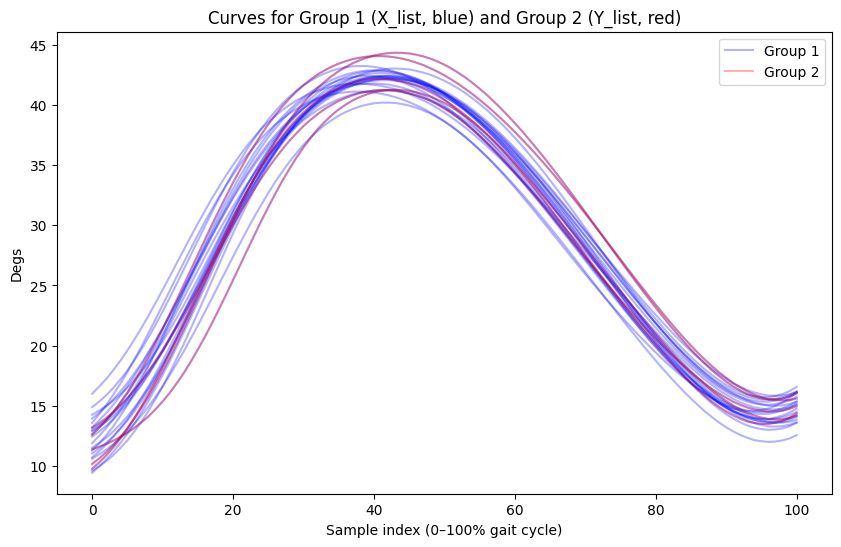


Results:
--------------------------------------------------
p-value = 7.44e-01 (0.744451)
TAN = 8.568  m* = 3


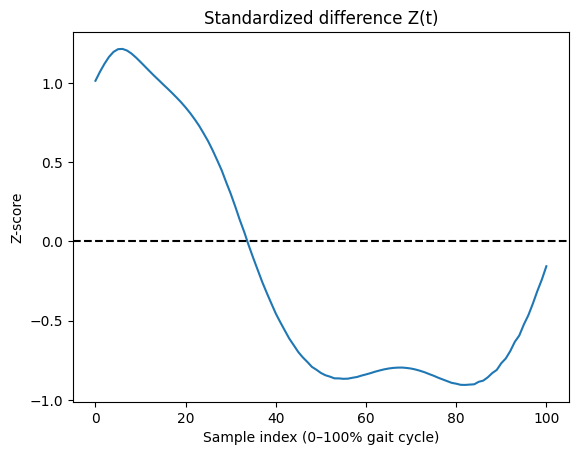

In [15]:
X_list =  group_1[:, :, 2]  # Only Z axis -> shape → (22, 101)
Y_list = X_list[5:10]

print("X_list shape: ", X_list.shape)
print("Y_list shape: ", Y_list.shape)

plt.figure(figsize=(10, 6))
for i in range(X_list.shape[0]):
    plt.plot(X_list[i], color='blue', alpha=0.3, label='Group 1' if i == 0 else "")
for i in range(Y_list.shape[0]):
    plt.plot(Y_list[i], color='red', alpha=0.3, label='Group 2' if i == 0 else "")
plt.title("Curves for Group 1 (X_list, blue) and Group 2 (Y_list, red)")
plt.xlabel("Sample index (0–100% gait cycle)")
plt.ylabel("Degs")
plt.legend()
plt.show()


result = compare_curve_groups_permutation(
    X_list, Y_list,
    register=False,       # safer default
    n_perm=5000,
    random_state=42
)

print("\nResults:")
print("-"*50)
print(f"p-value = {result['p_value']:.2e} ({result['p_value']:.6f})")
print(f"TAN = {result['TAN']:.3f}  m* = {result['m_star']}")

plt.plot(result['Z'])
plt.axhline(0, color='black', linestyle='--')
plt.title("Standardized difference Z(t)")
plt.xlabel("Sample index (0–100% gait cycle)")
plt.ylabel("Z-score")
plt.show()

=== 1 & 2 GROUPS ===
Observed TAN: 9.88713444309178
Permutation-based p-value: 0.0004997501249375312

=== 1 & 3 GROUPS ===
Observed TAN: 7.638659312083325
Permutation-based p-value: 0.0004997501249375312

=== 2 & 3 GROUPS ===
Observed TAN: 9.274795446864779
Permutation-based p-value: 0.0004997501249375312


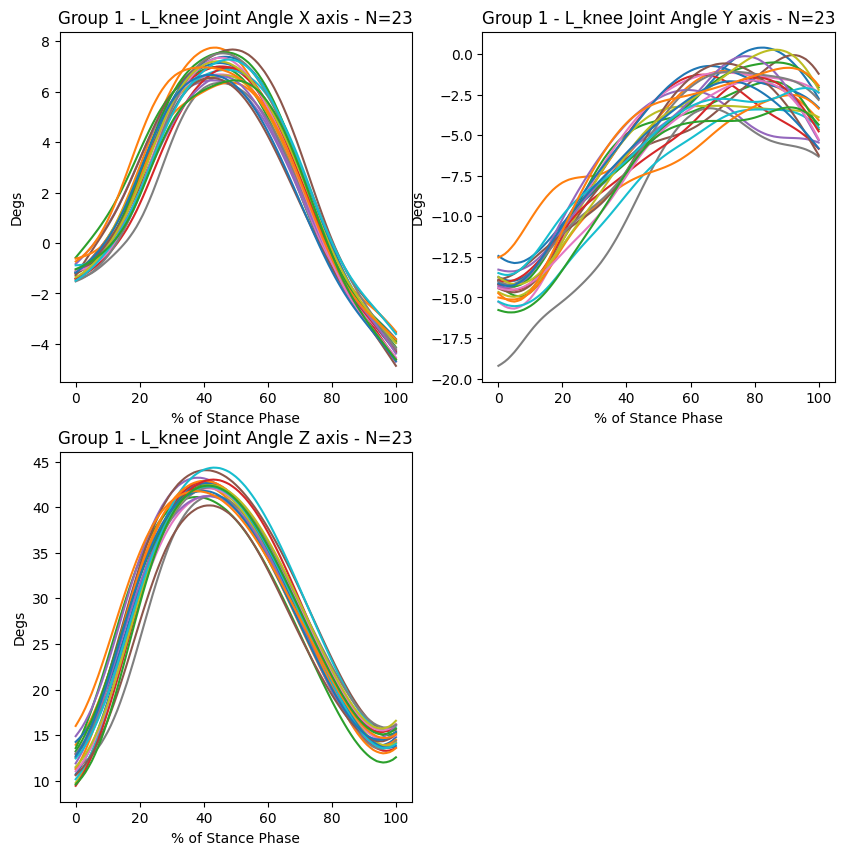

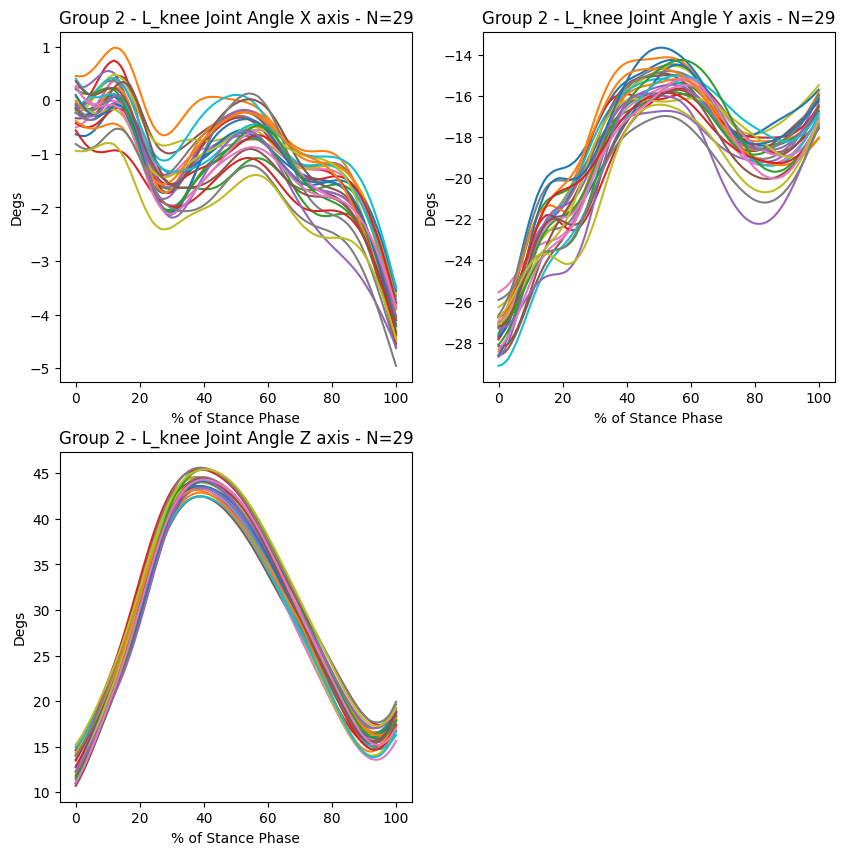

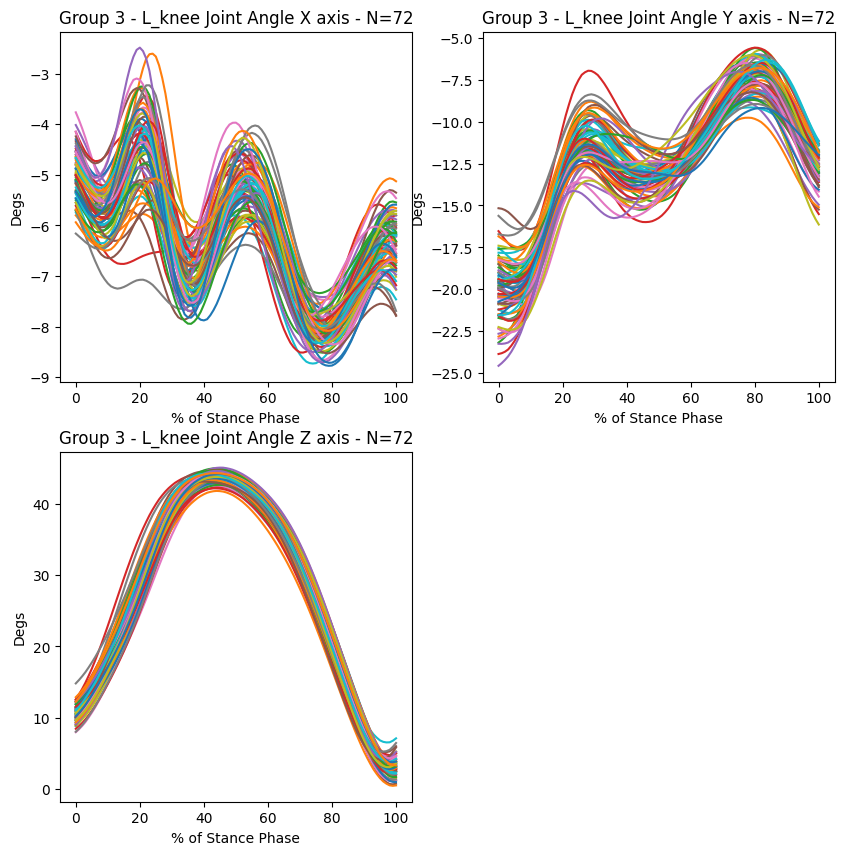

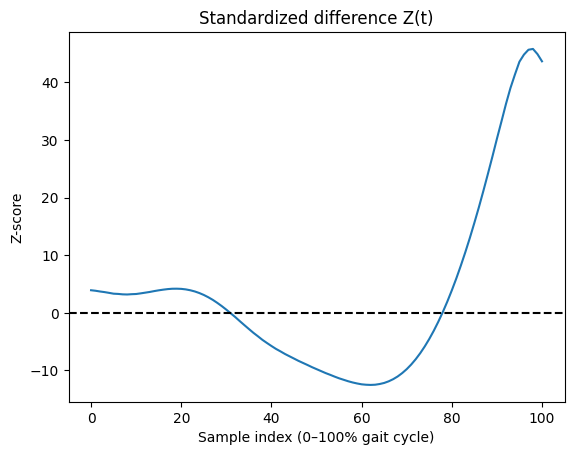

In [10]:
group3_session = loader.get_successful_sessions()[800]
group3_ts = loader.get_joint_angles_timeseries(group3_session, L_KNEE_JOINT_NAME, normalized=False, include_events=True)
group_3 = get_group_curves(group3_ts)
plot_group_curves(group_1, "Group 1", f"{L_KNEE_JOINT_NAME} Joint Angle", "Degs", "% of Stance Phase")
plot_group_curves(group_2, "Group 2", f"{L_KNEE_JOINT_NAME} Joint Angle", "Degs", "% of Stance Phase")
plot_group_curves(group_3, "Group 3", f"{L_KNEE_JOINT_NAME} Joint Angle", "Degs", "% of Stance Phase")

X_list = group_1[:, :, 2]
Y_list = group_2[:, :, 2]
# Y_list = X_list[2:4]
Y2_list = group_3[:, :, 2]

# ------------------------------
# Run tests
# ------------------------------
res_1_2 = compare_curve_groups_permutation(X_list, Y_list, register=False, n_perm=2000, random_state=1)
res_1_3 = compare_curve_groups_permutation(X_list, Y2_list, register=False, n_perm=2000, random_state=2)
res_2_3 = compare_curve_groups_permutation(Y_list, Y2_list, register=False, n_perm=2000, random_state=2)

print("=== 1 & 2 GROUPS ===")
print("Observed TAN:", res_1_2['TAN'])
print("Permutation-based p-value:", res_1_2['p_value'])

print("\n=== 1 & 3 GROUPS ===")
print("Observed TAN:", res_1_3['TAN'])
print("Permutation-based p-value:", res_1_3['p_value'])

print("\n=== 2 & 3 GROUPS ===")
print("Observed TAN:", res_2_3['TAN'])
print("Permutation-based p-value:", res_2_3['p_value'])

plt.figure()
plt.plot(res_1_3['Z'])
plt.axhline(0, color='black', linestyle='--')
plt.title("Standardized difference Z(t)")
plt.xlabel("Sample index (0–100% gait cycle)")
plt.ylabel("Z-score")
plt.show()

# Approach 2:

In [11]:
# P:
import numpy as np
from scipy.fft import fft
from scipy.interpolate import interp1d
from scipy.optimize import minimize

# Input:
X_curves = group_1[:,:,2]  # Only X axis
Y_curves = group_2[:,:,2]  # Only X axis

def compute_mean_variance(curves):
    mean_curve = np.mean(curves, axis=0)
    var_curve = np.var(curves, axis=0, ddof=1)
    return mean_curve, var_curve

def curve_registration(mu_X, mu_Y):
    # TODO: Check against paper...
    # Example: simple global shift alignment by minimizing squared difference
    # More sophisticated methods can be used (dynamic time warping, iterative warping)
    def cost(shift):
        shifted = np.roll(mu_Y, int(shift))
        return np.sum((mu_X - shifted)**2)

    res = minimize(cost, 0, bounds=[(-len(mu_Y)//2, len(mu_Y)//2)])
    shift_opt = int(res.x)
    mu_Y_registered = np.roll(mu_Y, shift_opt)
    return mu_X, mu_Y_registered

def standardized_difference(mu_X_r, mu_Y_r, var_X, var_Y, N_X, N_Y):
    se = np.sqrt(var_X / N_X + var_Y / N_Y)
    se[se == 0] = 1e-10  # Avoid division by zero
    Z = (mu_X_r - mu_Y_r) / se
    return Z

def adaptive_neyman_test(Z):
    T = len(Z)
    # Compute FFT
    Z_fft = fft(Z)
    K = T // 2

    # Form vector E with real and imaginary parts as described
    E = [Z_fft[0].real]
    for k in range(1, K + 1):
        E.append(Z_fft[k].real)
        E.append(Z_fft[k].imag)
    E = np.array(E)

    # Compute test statistics for m=1..len(E)
    def T_AN(m):
        Ei = E[:m]
        return np.sum(Ei**2 - 1) / np.sqrt(np.var(Ei**2, ddof=1))

    statistics = [T_AN(m) for m in range(1, len(E) + 1)]
    m_star = np.argmax(statistics) + 1
    T_AN_star = (statistics[m_star - 1] - m_star) / np.sqrt(2 * m_star)

    # p-value estimation would require simulation (not shown here)

    return T_AN_star, m_star

# Example procedure
N_X, T = X_curves.shape
N_Y, T_y= Y_curves.shape[0]

if T != T_y:
    raise ValueError("X and Y curves must have the same number of time points")

mu_X, var_X = compute_mean_variance(X_curves)
mu_Y, var_Y = compute_mean_variance(Y_curves)

mu_X_r, mu_Y_r = curve_registration(mu_X, mu_Y)

Z = standardized_difference(mu_X_r, mu_Y_r, var_X, var_Y, N_X, N_Y)

statistic, m_star = adaptive_neyman_test(Z)

def present_results(mu_X_r, mu_Y_r, Z, E, statistic, m_star):
    print(f"Adaptive Neyman test statistic (T_AN*): {statistic:.4f}")
    print(f"Optimal number of Fourier coefficients retained (m*): {m_star}")
    # p-value estimation requires simulation, here assume it is None or computed elsewhere
    print("P-value estimation requires Monte Carlo simulation (not computed here)")

    T = len(Z)
    K = T // 2
    freqs = np.arange(K + 1)

    # Plot registered mean curves
    plt.figure(figsize=(12, 8))
    plt.subplot(3, 1, 1)
    plt.plot(mu_X_r, label='Registered Mean Curve Group X')
    plt.plot(mu_Y_r, label='Registered Mean Curve Group Y')
    plt.title("Registered Mean Curves")
    plt.xlabel("Time (samples)")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True)

    # Plot standardized difference curve Z(t)
    plt.subplot(3, 1, 2)
    plt.plot(Z, label='Standardized Difference Z(t)')
    plt.title("Standardized Difference Curve")
    plt.xlabel("Time (samples)")
    plt.ylabel("Standardized Difference")
    plt.axhline(0, color='black', linestyle='--')
    plt.legend()
    plt.grid(True)

    # Plot Fourier coefficients (real and imaginary parts)
    plt.subplot(3, 1, 3)

    # Recall that E is structured as:
    # E[0] = Re(Z_fft[0])
    # E[1], E[2] = Re(Z_fft[1]), Im(Z_fft[1]), and so forth
    reals = [E[0]] + [E[i] for i in range(1, len(E), 2)]
    imags = [0] + [E[i] for i in range(2, len(E), 2)]  # imaginary part for k=0 is zero

    plt.stem(freqs, reals, linefmt='b-', markerfmt='bo', basefmt=' ', label='Real Parts')
    plt.stem(freqs, imags, linefmt='r-', markerfmt='ro', basefmt=' ', label='Imaginary Parts')
    plt.title("Fourier Coefficients of Standardized Difference")
    plt.xlabel("Frequency index k")
    plt.ylabel("Coefficient value")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Assuming after running your main analysis you have:
# mu_X_r, mu_Y_r, Z from the earlier code
# statistic, m_star from adaptive_neyman_test()

# Also construct vector E similarly to adaptive_neyman_test function
Z_fft = fft(Z)
T = len(Z)
K = T // 2
E = [Z_fft[0].real]
for k in range(1, K + 1):
    E.append(Z_fft[k].real)
    E.append(Z_fft[k].imag)
E = np.array(E)

# Present results
present_results(mu_X_r, mu_Y_r, Z, E, statistic, m_star)

TypeError: cannot unpack non-iterable int object